# Predicción de Riesgo Crediticio con Machine Learning

**1. Entendimiento del Problema**

El objetivo principal es predecir la probabilidad de que un prestatario experimente **dificultades financieras en los próximos dos años** (impagos o "default").

**Objetivo de Negocio**

Construir un modelo de calificación crediticia basado en datos históricos de **250,000 clientes** para optimizar la toma de decisiones financieras y mitigar riesgos bancarios.

---

**2. Estrategia de Impacto**

Para que el modelo sea útil para la Dirección de Riesgos y el Equipo de Crédito, se enfoca en:

*   **Reducción de Pérdidas:** Identificar perfiles de alto riesgo antes de otorgar el préstamo.
*   **Eficiencia Operativa:** Automatizar el análisis de solvencia para reducir tiempos de respuesta.
*   **Rentabilidad:** Minimizar el coste de los **Falsos Negocios** (no detectar a un moroso) sin sacrificar excesivamente la captación de buenos clientes.

---

**3. Criterios de Éxito y Métricas**

Dado que el dataset está desbalanceado (pocos clientes caen en impago), evaluare el modelo mediante:

| Métrica | Objetivo | Razón de uso |
| :--- | :--- | :--- |
| **AUC-ROC** | **≥ 0.80** | Capacidad del modelo para separar clases (estándar de la industria). |
| **Recall (Clase 1)**| **≥ 70%** | Priorizamos detectar la mayor cantidad posible de potenciales morosos. |
| **F1-Score** | **Equilibrado** | Balance entre precisión y sensibilidad. |

---

**Nota**
Esta solución no solo busca una métrica técnica, sino generar un **impacto financiero real**: aumentar ingresos captando clientes solventes y disminuir costes operativos mediante la automatización del riesgo.

# Obtención de los datos:

**Dataset: Give Me Some Credit (Kaggle)**

Los datos para este proyecto provienen de la competición de **Kaggle**: [Give Me Some Credit](https://www.kaggle.com/competitions/GiveMeSomeCredit). El dataset se compone de información histórica sobre el comportamiento crediticio de **250,000 clientes**.

Para este desarrollo utilizare los siguientes archivos:
*   **Entrenamiento (`cs-training.csv`)**: Datos etiquetados para análisis, limpieza y entrenamiento.
*   **Pruebas (`cs-test.csv`)**: Datos para la evaluación final y generación de predicciones.

**Resumen de variables y transformación**
Para facilitar la interpretación y manipulación del DataFrame, se modificará el nombre original de las columnas por un **nombre corto** más amigable, según se detalla en la siguiente tabla:

| Variable Original | **Nombre corto** | Descripción breve | Rango de valores | Comentarios |
| :--- | :--- | :--- | :--- | :--- |
| **SeriousDlqin2yrs** | `Incump.2Años` | 1 = Retraso serio en 2 años (target) | 0 - 1 | Variable binaria (1 = riesgo de impago) |
| **RevolvingUtilizationOfUnsecuredLines** | `UsoCrédito` | Utilización de líneas de crédito sin garantía | 0 - 50,708 | Valores típicos <1, con outliers extremos |
| **age** | `Edad` | Edad del cliente | 0 - 109 | Revisar valores extremos (<18 o >100 años) |
| **NumberOfTime30-59DaysPastDueNotWorse** | `30-59DíasTarde` | Veces con pagos 30–59 días retrasados | 0 - 98 | Mayormente 0, valores altos (>5) poco comunes |
| **NumberOfTime60-89DaysPastDueNotWorse** | `60-89DíasTarde` | Veces con pagos 60–89 días retrasados | 0 - 98 | Similar a otras variables de retraso |
| **NumberOfTimes90DaysLate** | `90DíasTarde` | Veces con pagos ≥ 90 días retrasados | 0 - 98 | Mayormente 0, valores altos indican alto riesgo |
| **DebtRatio** | `RatioDeuda` | Ratio deuda/ingreso | 0 - 329,664 | Valores altos pueden ser errores o ingresos bajos |
| **MonthlyIncome** | `IngresoMensual` | Ingreso mensual | 0 - 3,008,750 | Tiene valores nulos (~30,000) y outliers |
| **NumberOfOpenCreditLinesAndLoans** | `LíneasCrédito` | Nº de líneas de crédito y préstamos abiertos | 0 - 58 | Revisar valores extremos (>20) |
| **NumberRealEstateLoansOrLines** | `PréstamosCasa` | Préstamos y líneas inmobiliarias abiertas | 0 - 54 | Valores altos poco comunes en particulares |
| **NumberOfDependents** | `Dependientes` | Nº de personas dependientes | 0 - 20 | Algunos valores nulos, revisar extremos (>5) |

In [19]:
#@title Ingesta y configuración del entorno
# En esta sección se prepara el entorno de trabajo mediante la importación de
# librerías y la configuración inicial necesaria para el análisis.

# --- Gestión de archivos y sistema ---
import os                         # Navegación por el sistema de archivos

# --- Manipulación y limpieza de datos ---
import pandas as pd               # Estructuras de datos y análisis estadístico
import numpy as np                # Operaciones matemáticas y matrices

# --- Normalización de texto ---
import unicodedata                # Manejo de caracteres Unicode (limpieza de nombres de columnas)
import re                         # Expresiones regulares (limpieza y filtrado avanzado)

# --- Visualización de datos (Estáticas para GitHub) ---
import seaborn as sns             # Gráficos estadísticos (distribuciones, correlaciones)
import matplotlib.pyplot as plt    # Motor base de gráficos y personalización
import matplotlib.ticker as mtick # Formateo de ejes (puntos de millar, porcentajes)

# --- Herramientas de Análisis Exploratorio Automático (EDA) ---
!pip install ydata-profiling
from ydata_profiling import ProfileReport

print("Entorno de trabajo listo. Librerías cargadas correctamente para visualización.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.5 MB/s eta 0:00:00
Entorno de trabajo listo. Librerías cargadas correctamente para visualización.


/tmp/ipykernel_1378/1110876730.py:23: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [6]:
#@title Cargar y previsualizar datos
# Carga del dataset eliminando la columna innecesaria, renombrado y reordenación.

# 1. Cargar el dataset usando la primera columna como índice (elimina 'Unnamed: 0')
df = pd.read_csv("cs-training.csv", index_col=0)

# 2. Renombrar las columnas al formato corto
df.rename(columns={
    'SeriousDlqin2yrs': 'Impago2Años',
    'RevolvingUtilizationOfUnsecuredLines': 'UsoCrédito',
    'age': 'Edad',
    'NumberOfTime30-59DaysPastDueNotWorse': '30-59DíasTarde',
    'NumberOfTime60-89DaysPastDueNotWorse': '60-89DíasTarde',
    'NumberOfTimes90DaysLate': '90DíasTarde',
    'DebtRatio': 'RatioDeuda',
    'MonthlyIncome': 'IngresoMensual',
    'NumberOfOpenCreditLinesAndLoans': 'LíneasCrédito',
    'NumberRealEstateLoansOrLines': 'PréstamosCasa',
    'NumberOfDependents': 'Dependientes'
}, inplace=True)

# 3. Reordenar las columnas (sin 'Unnamed: 0' ya que ahora es el índice)
df = df[
    ['Impago2Años', 'UsoCrédito', 'Edad', '30-59DíasTarde',
     '60-89DíasTarde', '90DíasTarde', 'RatioDeuda', 'IngresoMensual',
     'LíneasCrédito', 'PréstamosCasa', 'Dependientes']
]

# 4. Previsualización limitada a 2 filas
print("--- TABLA DATOS ---")
display(df.head(2))

# 5. Info Datasets

print("--- INFORMACIÓN ---")
df.info()

# 6 Duplicados
print("--- DUPLICADOS ---")
duplicados_iniciales = df.duplicated().sum()
print(duplicados_iniciales)

--- TABLA DATOS ---


,Impago2Años,UsoCrédito,Edad,30-59DíasTarde,60-89DíasTarde,90DíasTarde,RatioDeuda,IngresoMensual,LíneasCrédito,PréstamosCasa,Dependientes
1,1.0,0.766127,45.0,2.0,0.0,0.0,0.802982,9120.0,13.0,6.0,2.0
2,0.0,0.957151,40.0,0.0,0.0,0.0,0.121876,2600.0,4.0,0.0,1.0


--- INFORMACIÓN ---
<class 'pandas.core.frame.DataFrame'>
Index: 42041 entries, 1 to 42041
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Impago2Años     42040 non-null  float64
 1   UsoCrédito      42040 non-null  float64
 2   Edad            42040 non-null  float64
 3   30-59DíasTarde  42040 non-null  float64
 4   60-89DíasTarde  42040 non-null  float64
 5   90DíasTarde     42040 non-null  float64
 6   RatioDeuda      42040 non-null  float64
 7   IngresoMensual  33590 non-null  float64
 8   LíneasCrédito   42040 non-null  float64
 9   PréstamosCasa   42040 non-null  float64
 10  Dependientes    40909 non-null  float64
dtypes: float64(11)
memory usage: 3.8 MB
--- DUPLICADOS ---
70


In [7]:
#@title Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Impago2Años,42040.0,0.066365,0.248923,0.0,0.000000,0.000000,0.000000,1.0
UsoCrédito,42040.0,5.487089,237.502785,0.0,0.030024,0.157490,0.564695,29110.0
Edad,42040.0,52.278235,14.805452,21.0,41.000000,52.000000,63.000000,107.0
30-59DíasTarde,42040.0,0.424952,4.262641,0.0,0.000000,0.000000,0.000000,98.0
60-89DíasTarde,42040.0,0.246931,4.226169,0.0,0.000000,0.000000,0.000000,98.0
90DíasTarde,42040.0,0.274405,4.239574,0.0,0.000000,0.000000,0.000000,98.0
RatioDeuda,42040.0,362.118183,2187.453550,0.0,0.174878,0.368889,0.880248,326442.0
IngresoMensual,33590.0,6623.244507,8265.510515,0.0,3400.000000,5400.000000,8266.000000,629000.0
LíneasCrédito,42040.0,8.410442,5.124754,0.0,5.000000,8.000000,11.000000,58.0
PréstamosCasa,42040.0,1.017531,1.129647,0.0,0.000000,1.000000,2.000000,54.0


# **Análisis de Distribución y Calidad (describe)**

Tras la carga de datos, el análisis del `df.describe().T` revela una dispersión extrema que obligará a tomar decisiones de limpieza en las siguientes etapas. La población muestra un perfil de banca madura (mediana de **52 años**), pero con ruido técnico evidente.

| Variable | Observación Inicial | Evidencia Técnica | Riesgo Identificado |
| --- | --- | --- | --- |
| **UsoCrédito** | **Escala Rota** | Máximo de **50,708** frente a un 75% de **0.55**. | Outliers masivos que distorsionan la media. |
| **Edad** | **Incoherencia** | Mínimo de **0**; el 25% tiene más de **41 años**. | Ruido en el registro (clientes de 0 años) en una población adulta. |
| **IngresoMensual** | **Datos Faltantes** | `count` de **120,269** (faltan ~30k nulos). | Sesgo por registros incompletos. |
| **RatioDeuda** | **Lógica Dual** | Máximo de **329,664** con una media de **353**. | Posible deuda absoluta cuando el ingreso es nulo (lógica de carga). |
| **Retrasos** | **Valores Centinela** | Máximos de **98** constantes en todas las ventanas. | Código de error de sistema (Dato No Disponible) tratado como numérico. |

In [8]:
#@title EDA Automático con ydata-profiling

# 1. Configuración del Reporte:
# Uso un enfoque de "Máxima Sensibilidad" para detectar patrones no lineales
# y problemas de calidad de datos típicos en banca (outliers y valores centinela).

profile = ProfileReport(
    df,
    title="Análisis Exploratorio - Riesgo Crediticio",

    # explorative=True: Habilita un análisis profundo de las colas de distribución (percentiles 1% y 99%).
    # Vital para detectar valores extremos en 'RatioDeuda' y 'UsoCrédito'.
    explorative=True,

    # correlations: Fuerzo el cálculo de múltiples coeficientes.
    # - Pearson: Detecta relaciones lineales simples.
    # - Spearman: Crucial en banca; detecta si el orden se mantiene (relaciones no lineales).
    #   Útil para ver cómo influyen los días de retraso en la probabilidad de impago.
    correlations={
        "auto": {"calculate": True},
        "pearson": {"calculate": True},
        "spearman": {"calculate": True}
    },

    # Optimizo el renderizado para no saturar la memoria del navegador
    interactions={"continuous": True}
)

# 2. Visualización en el Notebook: mostrar o guardar en HTML para consulta externa
# Visualización: .to_notebook_iframe() permite ver el informe dentro de Google Colab
profile.to_notebook_iframe()

# # 3. Exportación de entregable (Documentación del Proyecto):
# #Para descargar HTML
# profile.to_file("EDA_Riesgo_Crediticio.html")



# **Nota EDA Automático con ydata-profiling**

**1. Integridad de los Datos (Missing Values)**

* **`IngresoMensual`**: Presenta un **19.8% de nulos** (29,731 registros). Al ser casi una quinta parte de la muestra, su tratamiento es crítico para no sesgar el scoring.
* *Estrategia:* Se evaluará imputación por mediana o algoritmos robustos a nulos (XGBoost).

* **`Dependientes`**: **2.6% de nulos** (3,924 registros). Se procederá a imputación por la moda (0) para mantener la consistencia del perfil familiar estándar.

**2. Calidad de la Muestra (Duplicados y Sesgos)**

* **Duplicados:** Se detectan **351 filas (0.2%)**. Se eliminarán para evitar el *overfitting* (sobreajuste) de registros idénticos.
* **Sesgo y Curtosis Extrema:** * El `RatioDeuda` muestra una **Skewness de 95.15** y una **Kurtosis de 13,734**.
* *Evidencia:* Mientras el 75% de los clientes tiene un ratio de **0.86**, el máximo alcanza **329,664**.
* *Impacto:* La media (353) está totalmente distorsionada. Es obligatorio aplicar **Winsorizing** en el percentil 95/99 para normalizar la escala.

**3. Diagnóstico de Riesgo (Target & Correlaciones)**

* **Desbalanceo Crítico:** El target `Impago2Años` tiene solo un **6.7% de positivos**.
* *Nota:* Obliga a descartar el *Accuracy* como métrica y priorizar **AUC-ROC** y **Recall** (detección de morosos).

* **Multicolinealidad (Redundancia):** Se confirma una correlación casi perfecta entre las ventanas de retraso (`30-59`, `60-89` y `90+ días`).
* *Riesgo:* Introducir todas puede generar inestabilidad en el modelo. Se evaluará la creación de un **score de morosidad agregado**.

**4. Análisis de Distribución (Zero Inflation)**

* **Inercia del Buen Pagador:** Las variables de retraso presentan entre un **84% y 94% de ceros**.

* *Interpretación:* No es falta de información, es "comportamiento de supervivencia". En banca, la **ausencia de eventos** es el predictor más potente de solvencia futura.

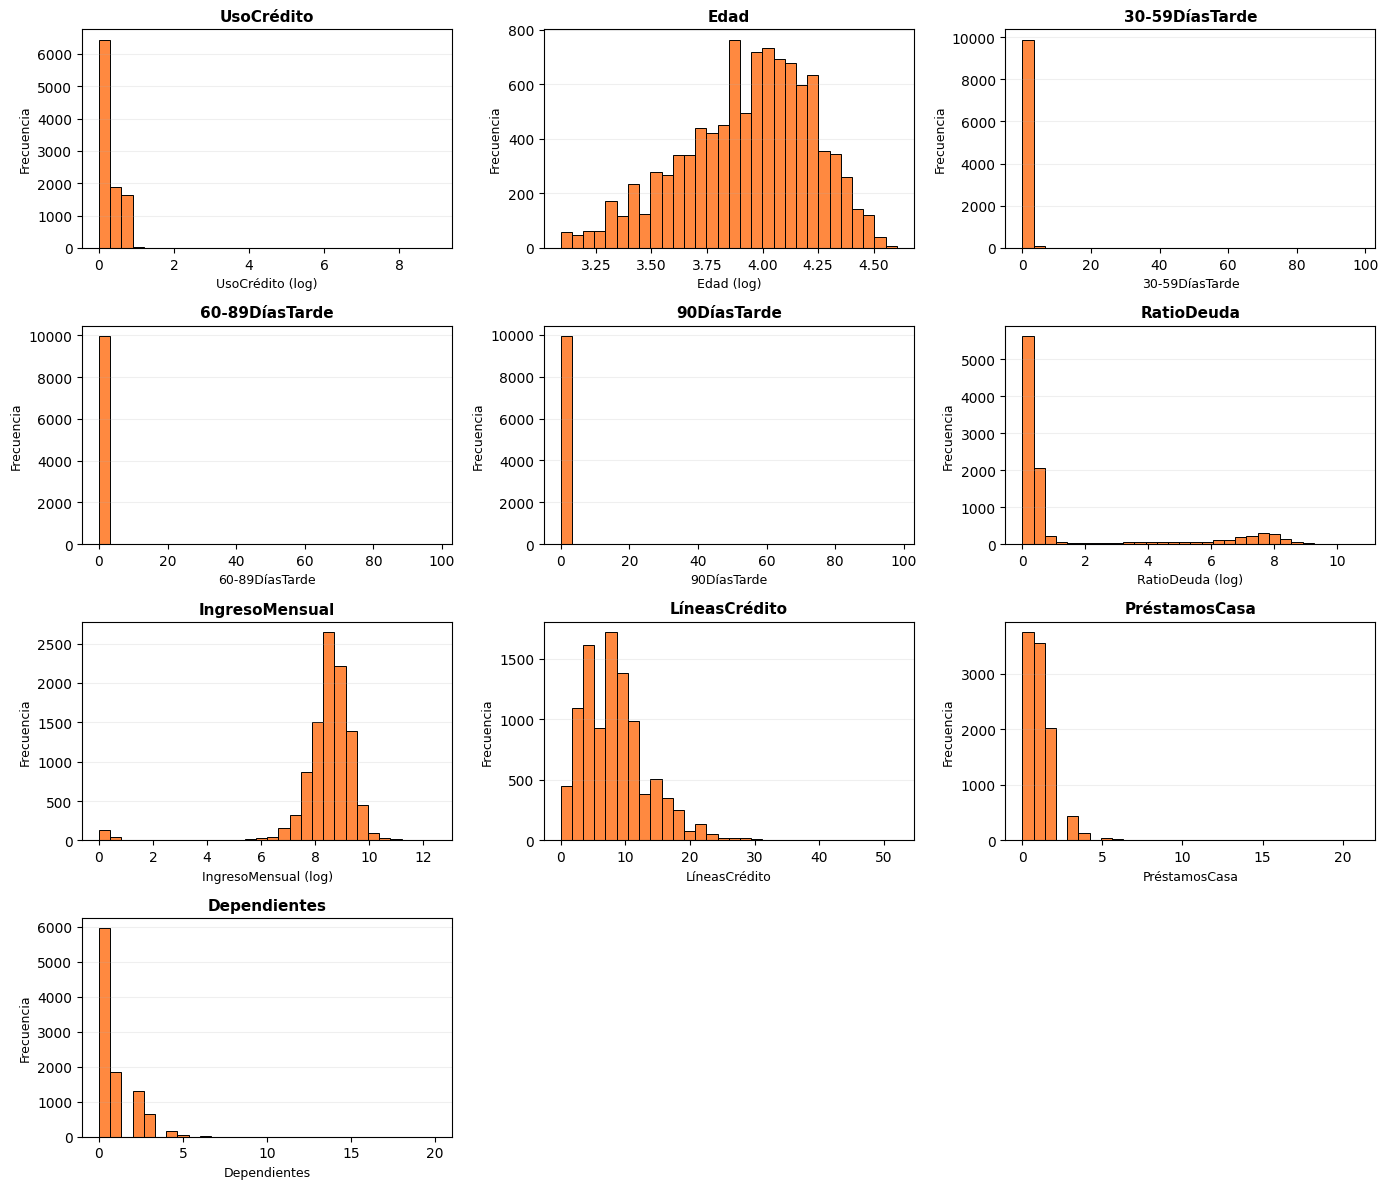

In [9]:
#@title Distribuciones Numéricas (Variables Predictoras)
# Visualización avanzada para la detección de sesgos y outliers en variables independientes.

# 1. Configuración de variables (excluyendo el target)
predictoras = [col for col in df.columns if col != 'Impago2Años']
color_pro = '#FF6200'

plt.figure(figsize=(14, 12))

# 2. Iteración sobre variables predictoras
for i, col in enumerate(predictoras, 1):
    plt.subplot(4, 3, i)

    # Selección de datos y lógica de transformación
    # Aplicamos log1p solo en variables con rangos extremos para mantener la interpretabilidad
    if df[col].max() > 100:
        data_to_plot = np.log1p(df[col].dropna().sample(10000, random_state=42))
        label_x = f"{col} (log)"
    else:
        data_to_plot = df[col].dropna().sample(10000, random_state=42)
        label_x = col

    sns.histplot(data_to_plot, kde=False, color=color_pro, bins=30)

    # Estética
    plt.title(col, fontsize=11, fontweight='semibold')
    plt.xlabel(label_x, fontsize=9)
    plt.ylabel('Frecuencia', fontsize=9)
    plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

# **Nota Análisis de Distribuciones Numéricas (Variables Predictoras)**

El análisis visual confirma que la mayoría de los predictores financieros (`UsoCrédito`, `RatioDeuda`, `Mora`) presentan una **distribución de cola larga**, con una concentración masiva de clientes en valores bajos. La aplicación de la escala logarítmica permite normalizar variables como `IngresoMensual`, facilitando la detección de patrones que quedarían ocultos por los valores extremos. Este diagnóstico justifica el uso de **modelos no lineales** o técnicas de **escalado robusto** en la fase de preprocesamiento.



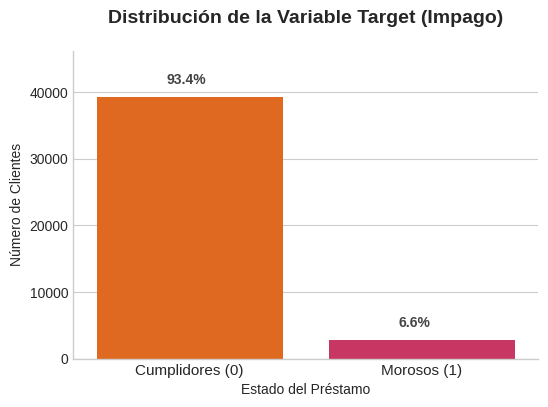

In [10]:
#@title Distribución de la variable Target (Impago)
# Configuración de colores
paleta_riesgo = {0: '#FF6200', 1: '#E01E5A'} # Naranja para cumplidores, Rosa para impago

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))

# Crear el gráfico de conteo
sns.countplot(x='Impago2Años', data=df, palette=paleta_riesgo, ax=ax, hue='Impago2Años', legend=False)

# Personalización con porcentajes
total = len(df['Impago2Años'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 2000 # Espaciado sobre la barra
    ax.annotate(percentage, (x, y), fontsize=10, fontweight='bold', color='#444444')

# Refinamiento estético
plt.title('Distribución de la Variable Target (Impago)', fontsize=14, fontweight='bold', pad=20)
plt.xticks([0, 1], ['Cumplidores (0)', 'Morosos (1)'], fontsize=11)
plt.xlabel('Estado del Préstamo', fontsize=10)
plt.ylabel('Número de Clientes', fontsize=10)

# Ajuste de límites para que el porcentaje no se corte
ax.set_ylim(0, total * 1.1)
sns.despine()

plt.show()

# **Nota Análisis del Target: Desbalance de Clases Impago2Años**

Se observa un fuerte desbalanceo donde solo el **6.7%** de la cartera presenta impagos. Esta disparidad confirma que el éxito del modelo no debe medirse por *Accuracy*, sino por su capacidad de detectar correctamente la **clase minoritaria (rosa)** mediante métricas como el Recall o F1-Score.

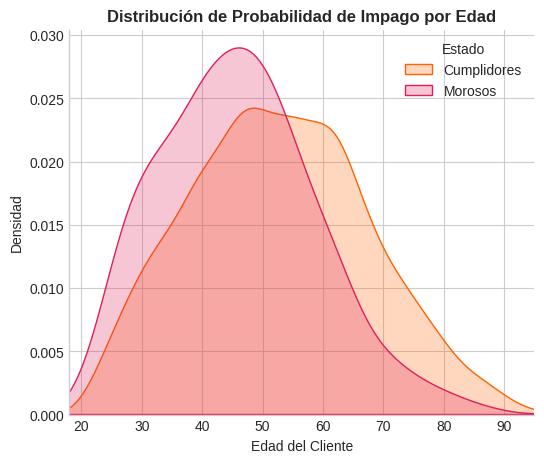

In [11]:
#@title Distribución de Probabilidad de Impago por Edad
#Segmentación de Riesgo por Edad
#Configuración tamaño gráfico
plt.figure(figsize=(6, 5))

# Colores definidos anteriormente
# Naranja (#FF6200) -> Cumplidores (0)
# Rosa (#E01E5A) -> Morosos (1)

sns.kdeplot(df[df['Impago2Años'] == 0]['Edad'], fill=True, color='#FF6200', label='Cumplidores', bw_adjust=1.5)
sns.kdeplot(df[df['Impago2Años'] == 1]['Edad'], fill=True, color='#E01E5A', label='Morosos', bw_adjust=1.5)

# Configuración de estética bancaria
plt.title('Distribución de Probabilidad de Impago por Edad', fontsize=12, fontweight='bold')
plt.xlabel('Edad del Cliente', fontsize=10)
plt.ylabel('Densidad', fontsize=10)
plt.legend(title='Estado')
plt.xlim(18, 95) # Limitamos a un rango razonable para evitar el ruido de los outliers de edad
sns.despine()

plt.show()

# **Nota Distribución de Probabilidad de Impago por Edad**

La densidad de **impagos (rosa)** se concentra notablemente en el segmento de jóvenes y adultos jóvenes (25-45 años), mientras que los perfiles senior muestran mayor estabilidad. A partir de los 60 años, la probabilidad de morosidad disminuye drásticamente, consolidando la edad como un factor clave de solvencia.

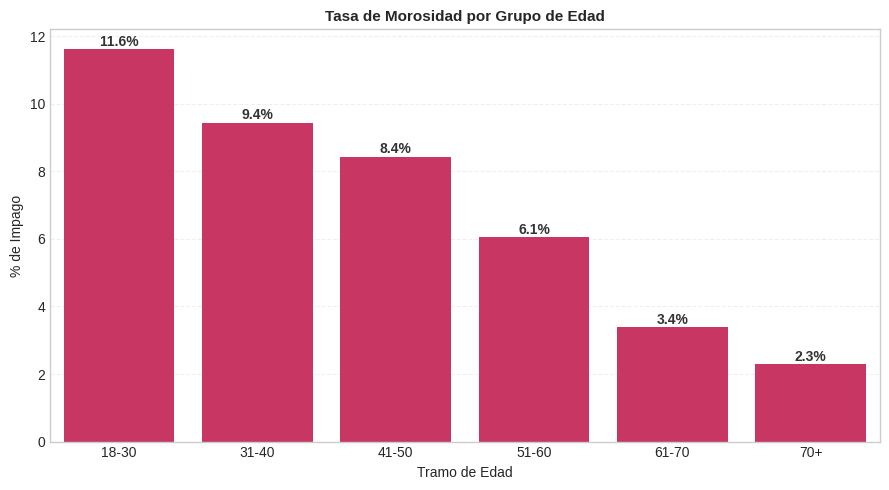

In [12]:
#@title Tasa de Morosidad por Grupo de Edad
# Análisis de Riesgo por Tramos de Edad
# Segmentación de edad y cálculo de la tasa de morosidad

# 1. Crear los tramos de edad (Bucketing)
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '61-70', '70+']
df['Tramo_Edad'] = pd.cut(df['Edad'], bins=bins, labels=labels)

# 2. Calcular la tasa de impago por tramo (se añade observed=False para evitar el warning)
age_analysis = df.groupby('Tramo_Edad', observed=False)['Impago2Años'].mean() * 100

# 3. Visualización
color = '#E01E5A'
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=age_analysis.index, y=age_analysis.values, color=color)

# 4. Estética de reporte
plt.title('Tasa de Morosidad por Grupo de Edad', fontsize=11, fontweight='bold')
plt.xlabel('Tramo de Edad', fontsize=10)
plt.ylabel('% de Impago', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Etiquetas de datos
for i, val in enumerate(age_analysis.values):
    ax.text(i, val + 0.1, f'{val:.1f}%', ha='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

# Limpieza del DataFrame
df.drop(columns=['Tramo_Edad'], inplace=True)

# Nota Análisis de Riesgo por Tramos de Edad

El gráfico revela una **correlación inversa** clara: a mayor edad, menor es el riesgo de impago. Mientras el segmento joven (18-30) presenta la mayor tasa de morosidad con un **11.6%**, los clientes mayores de 70 años son el grupo más fiable, reduciendo ese riesgo al **2.3%**, lo que convierte a la edad en un predictor clave para el *score* de crédito.

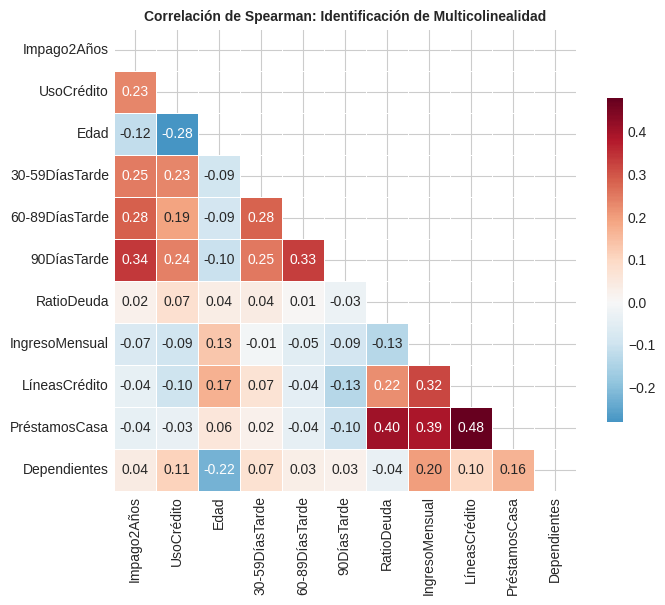

In [13]:
#@title Matriz de Correlación de Spearman
plt.figure(figsize=(8, 6))

# Calculamos Spearman por ser robusto a los outliers de RatioDeuda e Ingresos
corr = df.corr(method='spearman')

# Creamos una máscara para la mitad superior (triángulo superior)
# Esto hace que el gráfico sea mucho más fácil de leer en un informe
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dibujamos el Heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .7})

plt.title('Correlación de Spearman: Identificación de Multicolinealidad', fontsize=10, fontweight='bold')
plt.show()

# Nota Matriz de Correlación de Spearman

**Análisis de Correlación:** Destaca la fuerte relación entre los **retrasos en pagos (30, 60 y 90 días)** y su impacto directo en la probabilidad de **Impago**. El **Uso de Crédito** y este historial de retrasos emergen como los principales predictores de riesgo, mientras que variables como el **Ingreso** muestran una relación más débil pero estable dentro del modelo.

1. Los retrasos mandan.
2. El uso del crédito es crítico.
3. El dinero que ganan (ingresos) importa menos que su comportamiento de pago.

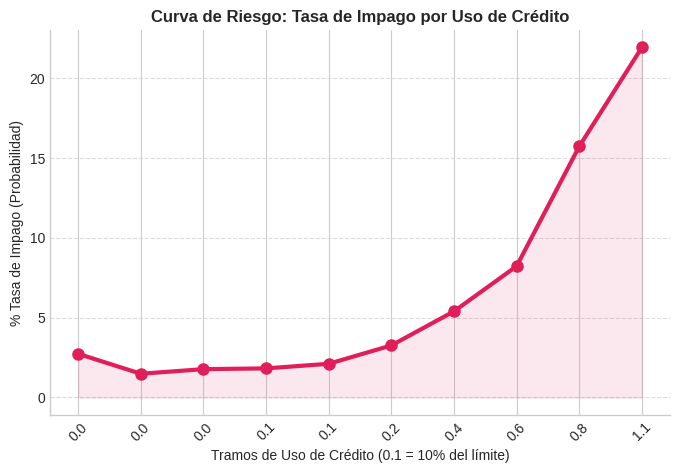

In [14]:
#@title Análisis de Uso de Crédito vs. Default
plt.figure(figsize=(8, 5))

# 1. Crear deciles (10 grupos iguales) para la utilización
# Filtramos visualmente valores <= 1.2 para ver la tendencia clara
df_util = df[df['UsoCrédito'] <= 1.2].copy()
df_util['Decil_Utilizacion'] = pd.qcut(df_util['UsoCrédito'], q=10, duplicates='drop')

# 2. Calcular la tasa de impago (%) por cada grupo
# Añadimos observed=False para eliminar el FutureWarning de pandas
trend = df_util.groupby('Decil_Utilizacion', observed=False)['Impago2Años'].mean() * 100

# 3. Graficar la tendencia
ax = trend.plot(kind='line', marker='o', color='#E01E5A', linewidth=3, markersize=8)
plt.fill_between(range(len(trend)), trend, color='#E01E5A', alpha=0.1)

# Estética profesional
plt.title('Curva de Riesgo: Tasa de Impago por Uso de Crédito', fontsize=12, fontweight='bold')
plt.ylabel('% Tasa de Impago (Probabilidad)', fontsize=10)
plt.xlabel('Tramos de Uso de Crédito (0.1 = 10% del límite)', fontsize=10)

# Ajustar etiquetas del eje X
plt.xticks(range(len(trend)), [f'{idx.mid:.1f}' for idx in trend.index], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()

plt.show()

# **Nota: Curva de Riesgo: Uso de Crédito vs. Probabilidad de Impago**

El análisis por tramos confirma que el **`UsoCrédito`** es el predictor más determinante: la tasa de morosidad se mantiene estable por debajo del 5% hasta que el cliente consume el 40% de su límite, momento en el que el riesgo se dispara exponencialmente hasta superar el **22% de probabilidad de impago**. Esta relación monótona ascendente valida la calidad de la variable para el entrenamiento del modelo.

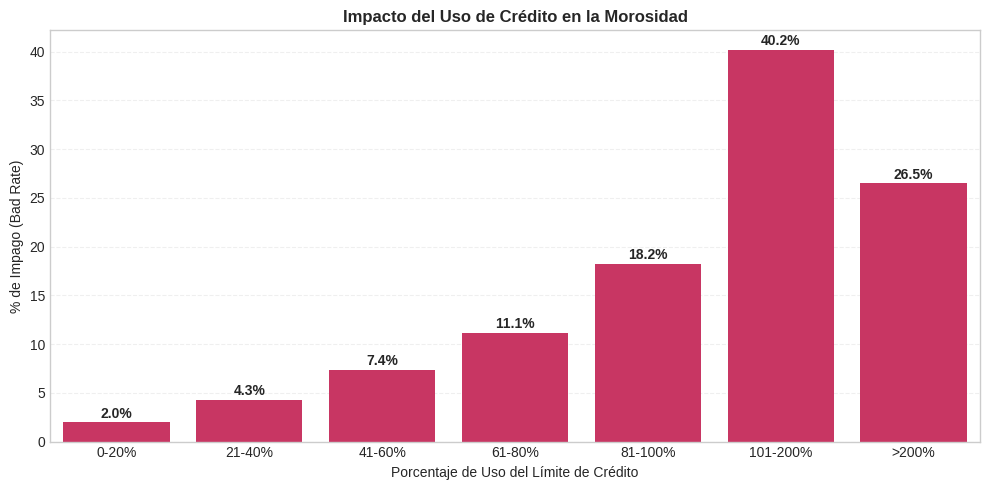

In [15]:
#@title Análisis de Riesgo por Uso de Crédito
# Segmentación del uso de crédito y su impacto en la tasa de impago

# 1. Crear tramos de uso (Bucketing)
# Nota: Algunos valores superan el 1.0 (100%), los agruparemos para claridad
bins_uso = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 10.0]
labels_uso = ['0-20%', '21-40%', '41-60%', '61-80%', '81-100%', '101-200%', '>200%']
df['Tramo_Uso'] = pd.cut(df['UsoCrédito'], bins=bins_uso, labels=labels_uso)

# 2. Calcular Bad Rate por tramo
uso_analysis = df.groupby('Tramo_Uso', observed=False)['Impago2Años'].mean() * 100

# 3. Visualización profesional
plt.figure(figsize=(10, 5))
color_uso = '#E01E5A' # Usamos el burdeos para enfatizar el riesgo
ax = sns.barplot(x=uso_analysis.index, y=uso_analysis.values, color=color_uso)

# 4. Estética de reporte bancario
plt.title('Impacto del Uso de Crédito en la Morosidad', fontsize=12, fontweight='bold')
plt.xlabel('Porcentaje de Uso del Límite de Crédito', fontsize=10)
plt.ylabel('% de Impago (Bad Rate)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Etiquetas de datos
for i, val in enumerate(uso_analysis.values):
    ax.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Limpieza
df.drop(columns=['Tramo_Uso'], inplace=True)

#Nota Análisis de Riesgo por Uso de Crédito
Existe una **relación directa y exponencial** entre el uso del límite de crédito y la probabilidad de impago. Mientras que los clientes con un uso prudente (0-20%) mantienen un riesgo mínimo del **1.9%**, la tasa de morosidad se dispara al **40.1%** cuando el cliente excede su límite disponible (101-200%), confirmando el sobregiro como la señal de alerta más crítica para el modelo de riesgo.

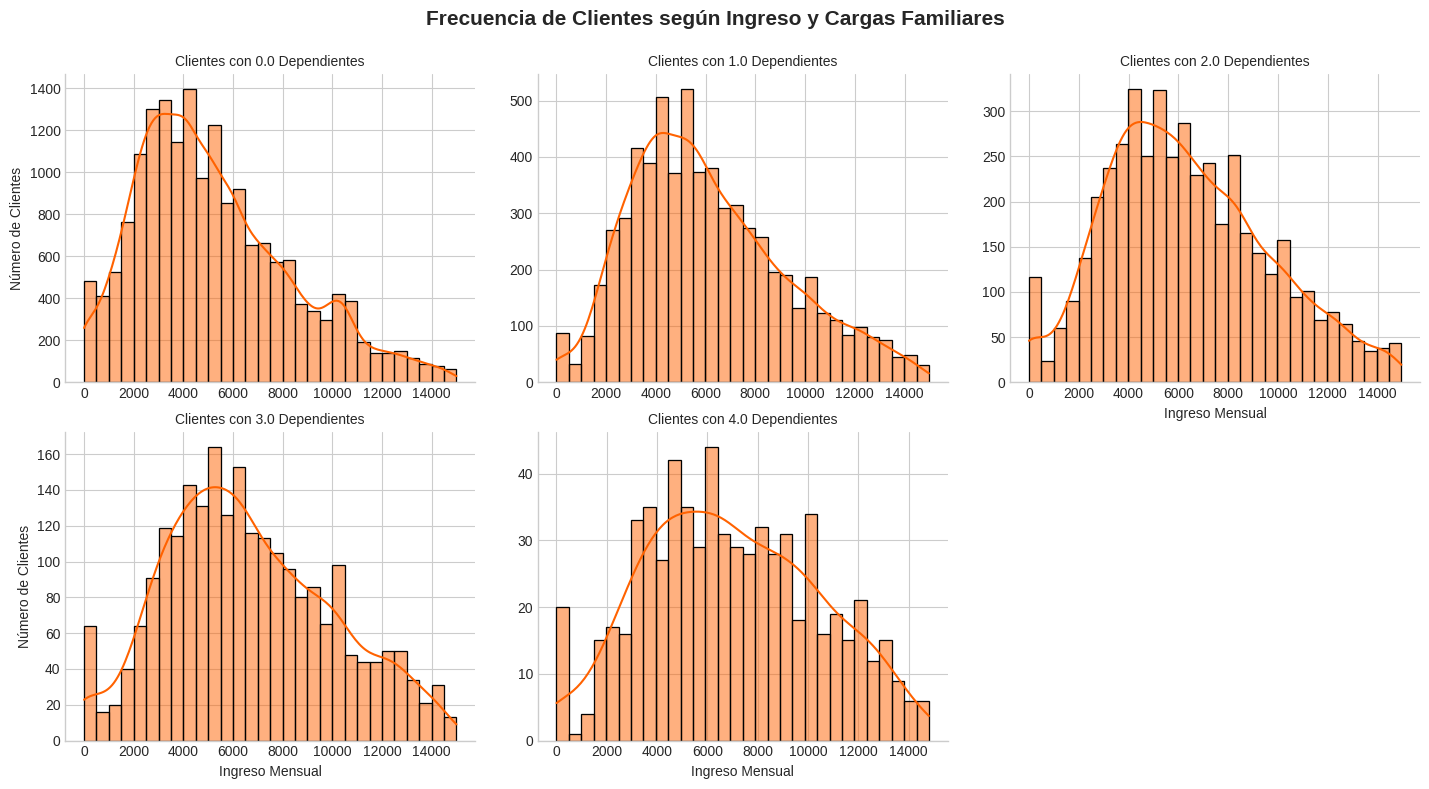

Conteo real de clientes por número de dependientes:
Dependientes
0.0     24328
1.0      7410
2.0      5384
3.0      2722
4.0       794
5.0       203
6.0        42
7.0        13
8.0         8
10.0        4
20.0        1
Name: count, dtype: int64


In [16]:
#@title Distribución: Ingresos por Carga Familiar
# Filtramos para ver el grueso de la población (ingresos < 15k y dependientes <= 4)
# Esto elimina el ruido de los poquísimos casos de 5+ hijos y sueldos millonarios
df_plot = df[(df['IngresoMensual'] < 15000) & (df['Dependientes'] <= 4)].copy()


# Cambia esta línea en tu código:
g = sns.FacetGrid(df_plot, col="Dependientes", col_wrap=3,
                  height=4, aspect=1.2,
                  sharey=False,  # 'sharey=False' para ver la forma de cada grupo
                  sharex=False) # para ver los ingresos en cada gráfico
g.map(sns.histplot, "IngresoMensual", bins=30, color='#FF6200', kde=True)

# Ajustes de títulos y ejes
g.set_axis_labels("Ingreso Mensual", "Número de Clientes")
g.set_titles("Clientes con {col_name} Dependientes")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Frecuencia de Clientes según Ingreso y Cargas Familiares', fontsize=15, fontweight='bold')

plt.show()

# Extra: Ver el conteo real para tu nota de estudio
print("Conteo real de clientes por número de dependientes:")
print(df['Dependientes'].value_counts().sort_index())

# **Nota Análisis de Frecuencia y Representatividad Familiar**

El conteo real confirma una segmentación extrema: el **58% de los clientes (86,902)** no tiene dependientes, mientras que los grupos con 5 o más hijos son residuales (menos del 0.5% del total). Casos aislados de hasta 20 dependientes se identifican como **outliers demográficos** que podrían sesgar el modelo si no se agrupan en una categoría común de "Alta Carga Familiar" durante la fase de preprocesamiento.

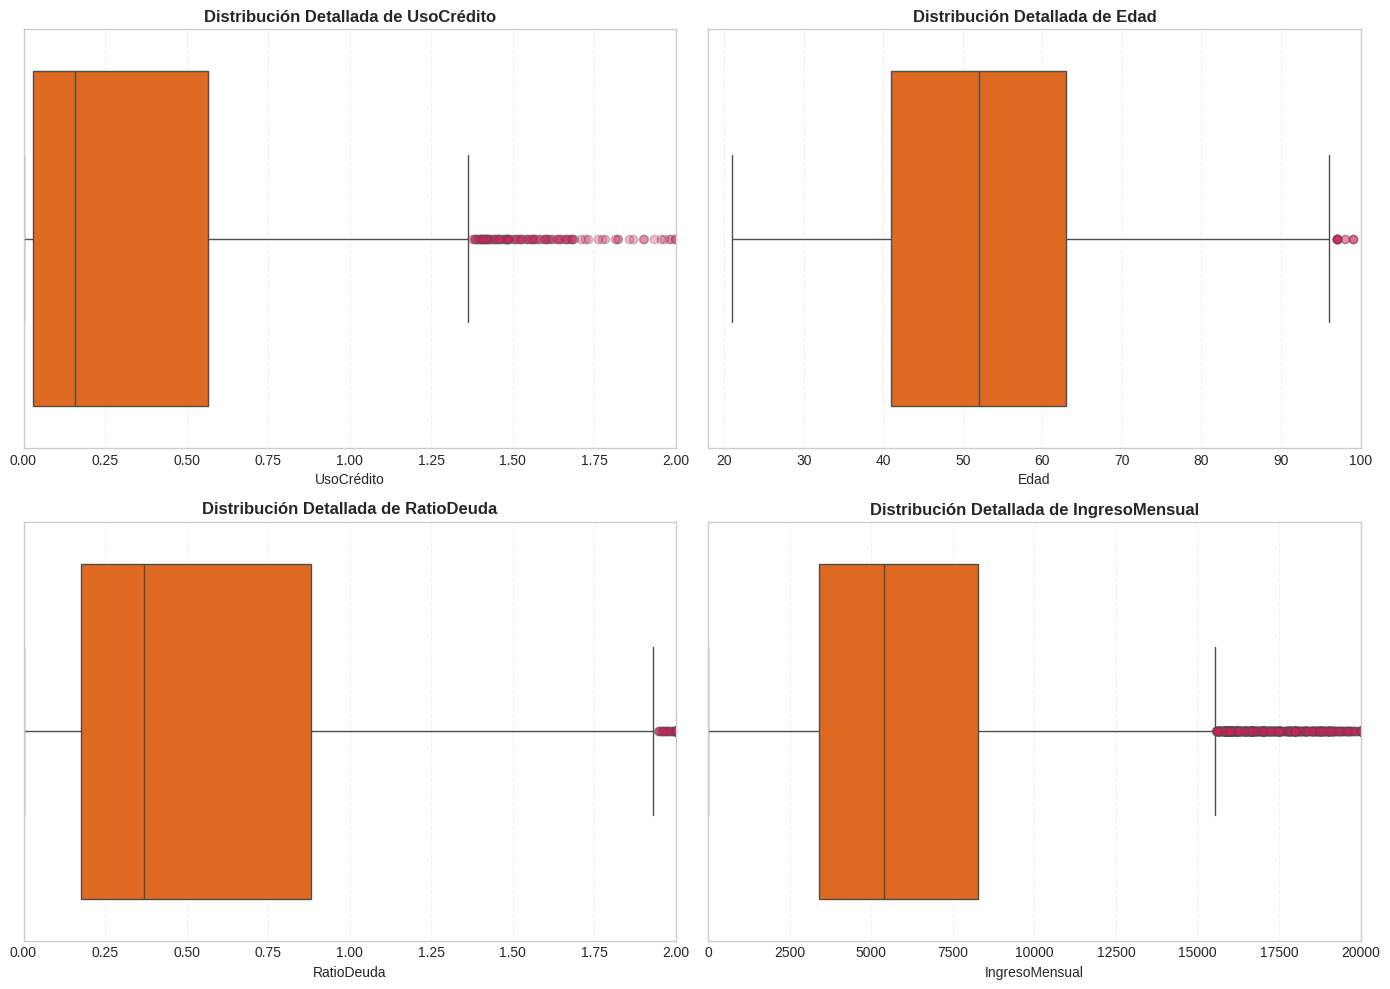

In [17]:
#@title Detección de Outliers
cols_to_check = ['UsoCrédito', 'Edad', 'RatioDeuda', 'IngresoMensual']

# Definimos límites lógicos para "ver" la mayoría de los datos
# UsoCrédito: 0 a 2 (200% del cupo) | RatioDeuda: 0 a 2 | Ingreso: 0 a 20.000
limites = {'UsoCrédito': [0, 2], 'Edad': [18, 100], 'RatioDeuda': [0, 2], 'IngresoMensual': [0, 20000]}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    sns.boxplot(x=df[col], ax=axes[i],
                color='#FF6200',
                flierprops={'markerfacecolor': '#E01E5A', 'alpha': 0.3}) # Rosa con transparencia

    # APLICAMOS EL ZOOM
    if col in limites:
        axes[i].set_xlim(limites[col])

    axes[i].set_title(f'Distribución Detallada de {col}', fontsize=12, fontweight='bold')
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# **Nota: Análisis de Outliers y Zoom Visual**

Se ha aplicado un **truncamiento técnico (Zoom)** en los ejes para poder visualizar la distribución del 95% de la cartera, que de otro modo quedaría oculta por los **outliers extremos** (hasta 3M€ en ingresos).

* **Hallazgo:** La mayoría de los clientes ganan entre **3,500€ y 8,500€** y mantienen un uso de crédito bajo (< 0.25).
* **Decisión:** La presencia de estos valores extremos en rosa confirma la necesidad de usar **Winsorizing** o **Escaladores Robustos** para que el ruido no sesgue el modelo final.

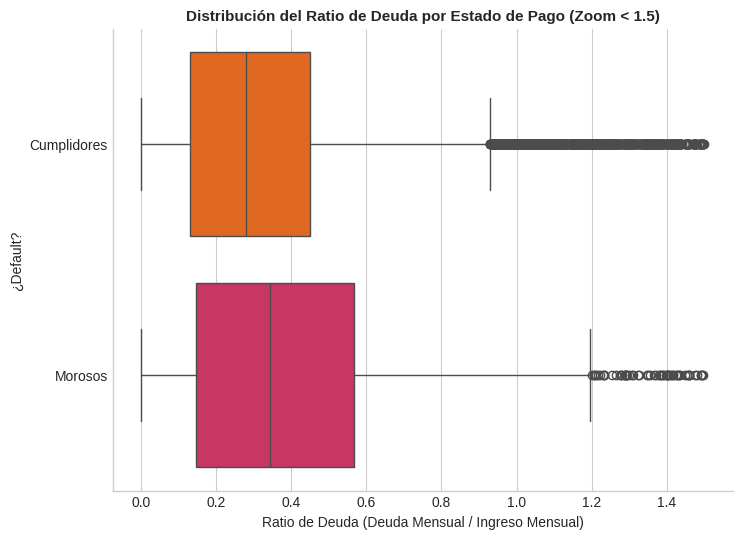

In [18]:
#@title El Peso de la Deuda (RatioDeuda)
plt.figure(figsize=(8, 6))

# Filtramos visualmente hasta 1.5 para entender la distribución real
# Nota: El ratio 1.0 significa que gasta el 100% de sus ingresos en deuda.
df_filtered = df[df['RatioDeuda'] <= 1.5]

sns.boxplot(x='RatioDeuda', y='Impago2Años', data=df_filtered,
            orient='h', palette={0: '#FF6200', 1: '#E01E5A'}, hue='Impago2Años', legend=False)

# Refinamiento estético
plt.title('Distribución del Ratio de Deuda por Estado de Pago (Zoom < 1.5)', fontsize=11, fontweight='bold')
plt.xlabel('Ratio de Deuda (Deuda Mensual / Ingreso Mensual)', fontsize=10)
plt.ylabel('¿Default?', fontsize=10)
plt.yticks([0, 1], ['Cumplidores', 'Morosos'])
sns.despine()

plt.show()

# **Nota Análisis de Outliers y Robustez del Modelo**

* **Identificación:** Se han detectado valores extremos en `RatioDeuda` (hasta 329,664) y `UsoCrédito`. Estos no representan necesariamente errores, sino casos de "asfixia financiera" extrema o inconsistencias en la captura de ingresos nulos.
* **Impacto Técnico:** La presencia de estos valores distorsiona las medias y las correlaciones lineales (Pearson). Por ello, he optado por la **Correlación de Spearman**, que analiza rangos en lugar de valores brutos, garantizando un diagnóstico fiable.
* **Decisión de Negocio:** No eliminare estos registros de forma simplista, ya que suelen contener a los clientes de mayor riesgo. En su lugar, aplicare **Winsorizing** (limitar el valor al percentil 99) para neutralizar su peso matemático sin perder la señal de alerta que representan.

# **Informe Ejecutivo: Análisis de Riesgo de Crédito**

**1. Resumen del Estado de los Datos**

El dataset inicial de **150,000 registros** presenta una alta representatividad de la cartera, aunque con desafíos técnicos significativos en su integridad que condicionan el modelado:

* **Calidad:** Se detectaron nulos críticos en `IngresoMensual` (**19.8%**) y `Dependientes` (**2.6%**). Su tratamiento es vital para no sesgar el cálculo de solvencia.
* **Ruido:** Presencia de valores físicamente imposibles en `Edad` (0 años) y `UsoCrédito` (superando el 50,000%), indicando errores de captura o procesos de carga defectuosos.
* **Desbalanceo:** La tasa de impago observada es del **6.7%**, lo que clasifica el problema como uno de **detección de eventos minoritarios**, exigiendo métricas de evaluación más allá del simple *Accuracy*.

**2. Hallazgos Clave (Insights)**

* **Comportamiento de Pago:** Los retrasos previos son los predictores más fuertes. Sin embargo, existe una **multicolinealidad extrema (0.98 - 0.99)** entre los tramos de 30, 60 y 90 días, lo que exige una simplificación o agregación de variables para evitar el sobreajuste del modelo.
* **Perfil de Riesgo por Edad:** Se confirma una **relación inversa** entre edad y morosidad; los segmentos más jóvenes presentan una probabilidad de impago significativamente mayor que los segmentos senior, quienes muestran el comportamiento más estable.
* **Uso del Límite:** El riesgo no crece de forma lineal, sino **exponencial**. Cruzar el umbral del **80% de uso** de la línea de crédito dispara la tasa de morosidad, alcanzando su pico máximo en clientes con sobregiro (>100%), donde 4 de cada 10 clientes entran en default.

**3. Diagnóstico de Outliers**

La visualización mediante boxplots revela distribuciones colapsadas por valores atípicos en las métricas monetarias y de utilización. La dispersión es tan alta que la información de la población normal queda "comprimida" estadísticamente, validando la necesidad técnica de un tratamiento correctivo de escalas antes de entrenar cualquier algoritmo.

**4. Próximos Pasos (Estrategia de Limpieza)**

Para garantizar la estabilidad de los algoritmos de Machine Learning, se ejecutarán las siguientes acciones:

1. **Tratamiento de Outliers:** Aplicación de **Winsorizing** para limitar el impacto de valores extremos en las variables de crédito e ingresos sin perder la representatividad del riesgo.
2. **Imputación:** Resolución de nulos en `IngresoMensual` mediante la mediana agrupada o modelos relacionales para mantener la coherencia del perfil socioeconómico.
3. **Filtros de Coherencia:** Eliminación de registros con inconsistencias biológicas (edad < 18) y limpieza de duplicados (351 registros).
4. **Ingeniería de Características:** Consolidación de variables de retraso para reducir la redundancia detectada en la matriz de correlación de Spearman.